In [22]:
import pandas as pd
import numpy as np 
df =pd.read_csv("C:\\Users\\MY PC\\Downloads\\laptops_data.csv")
df.head()

,title,price,rating,brand,ram,storage,color,processor
0,"HP Omnibook 3, Snapdragon X Processor 45 Tops ...","69,990",3.2,HP,16GB,512GB,Silver,Snapdragon
1,"Acer Smartchoice Aspire One, AMD Ryzen 5-40,Of...","49,990",3.7,Acer,8GB,512GB,Silver,AMD
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,"44,999",4.0,Lenovo,8GB,512GB,Silver,AMD
3,"ASUS Vivobook 15, Smartchoice,Intel Core i5 13...","65,990",4.1,ASUS,16GB,512GB,Blue,Intel
4,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,"73,990",4.8,Apple,8GB,256GB,Indigo,NaN


In [19]:
# show missing value
df.isna().sum()

title          0
price          5
rating        61
brand          0
ram           34
storage       44
color         82
processor    162
dtype: int64

In [20]:
# missing percentage per columns
df = df.isnull().sum()
missing = (df / len(df)) * 100

print(missing)

title           0.0
price          62.5
rating        762.5
brand           0.0
ram           425.0
storage       550.0
color        1025.0
processor    2025.0
dtype: float64


In [23]:
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price'] = df['price'].fillna(0)
df['price'].isnull().sum()

np.int64(0)

In [24]:
# replace all missing value by median 
df['rating'] = df['rating'].fillna(df['rating'].median())
df['rating'] = df['rating'].fillna(0)
df['rating'].isnull().sum()

np.int64(0)

In [25]:
# print all unique value in ram column
print(df['ram'].unique())

['16GB' '8GB' '36GB' 'RAM' 'LPDDR4' 'DDR5' '4GB' '12GB' '24GB' '6GB' nan
 'LPDDR5' '32GB' 'DDR5 ' '128GB' 'DDR7' '48GB' '64GB']


In [26]:
# convert ram into numeric 
df['ram'] = df['ram'].str.extract(r'(\d+)', expand=False)
df['ram'] = pd.to_numeric(df['ram'], errors='coerce')

In [27]:
df['ram'] = df['ram'].fillna(0)
df['ram'].isnull().sum()

np.int64(0)

In [28]:
# replace storage TB into GB:
df['storage'] = df['storage'].str.upper().str.strip()

df['storage'] = df['storage'].str.replace('TB', '000', regex=False)
df['storage'] = df['storage'].str.replace('GB', '', regex=False)

df['storage'] = pd.to_numeric(df['storage'], errors='coerce')
df['storage'] = df['storage'].fillna(0)
df['storage'].isnull().sum()

np.int64(0)

In [29]:
# check is any unknown color columns is there
df['color'] = df['color'].str.strip()
df['color'] = df['color'].replace('', pd.NA)
df['color'] = df['color'].fillna('Unknown')
df['color'].isnull().sum()

np.int64(0)

In [30]:
# convert all missing value into zero or isnull()
df['processor'] = df['processor'].str.strip()
df['processor'] = df['processor'].replace('', pd.NA)
df['processor'] = df['processor'].fillna('Unknown')
df['processor'].isnull().sum()

np.int64(0)

In [31]:
# check there is any missing values 
df.isna().sum()

title        0
price        0
rating       0
brand        0
ram          0
storage      0
color        0
processor    0
dtype: int64

In [32]:
# save the cleaned data in csv format
df.to_csv('cleaned_laptop_data.csv', index=False)

In [33]:
# check file exist or not:
import os

print(os.path.exists('cleaned_laptop_data.csv'))

True


In [34]:
import pandas as pd

df = pd.read_csv('cleaned_laptop_data.csv')

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df.head(5)

,title,price,rating,brand,ram,storage,color,processor
0,"HP Omnibook 3, Snapdragon X Processor 45 Tops ...",69990.0,3.2,HP,16.0,512.0,Silver,Snapdragon
1,"Acer Smartchoice Aspire One, AMD Ryzen 5-40,Of...",49990.0,3.7,Acer,8.0,512.0,Silver,AMD
2,Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8...,44999.0,4.0,Lenovo,8.0,512.0,Silver,AMD
3,"ASUS Vivobook 15, Smartchoice,Intel Core i5 13...",65990.0,4.1,ASUS,16.0,512.0,Blue,Intel
4,Apple 2026 MacBook Neo 13″ Laptop with A18 Pro...,73990.0,4.8,Apple,8.0,256.0,Indigo,Unknown


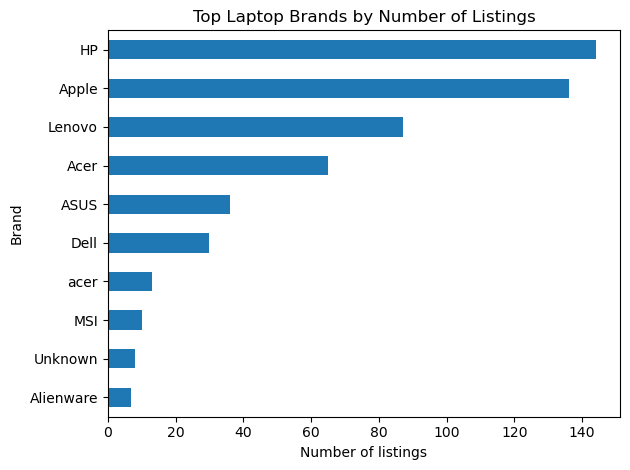

In [40]:
import matplotlib.pyplot as plt

brand_counts = df["brand"].value_counts().head(10)
brand_counts.sort_values().plot(kind="barh")
plt.title("Top Laptop Brands by Number of Listings")
plt.xlabel("Number of listings")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

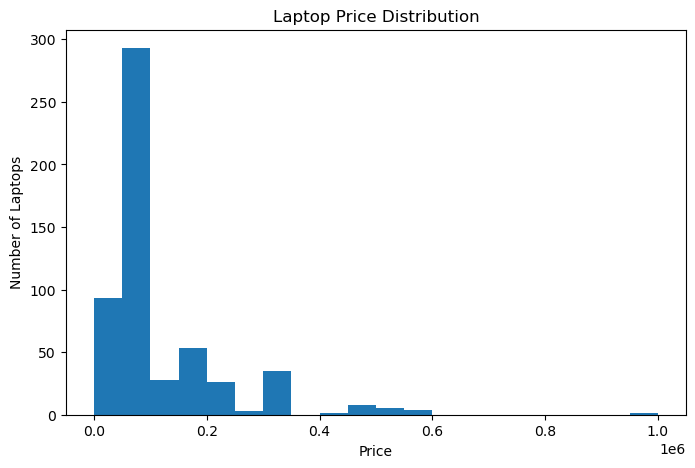

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(df['price'], bins=20)

plt.xlabel('Price')
plt.ylabel('Number of Laptops')
plt.title('Laptop Price Distribution')

plt.show()

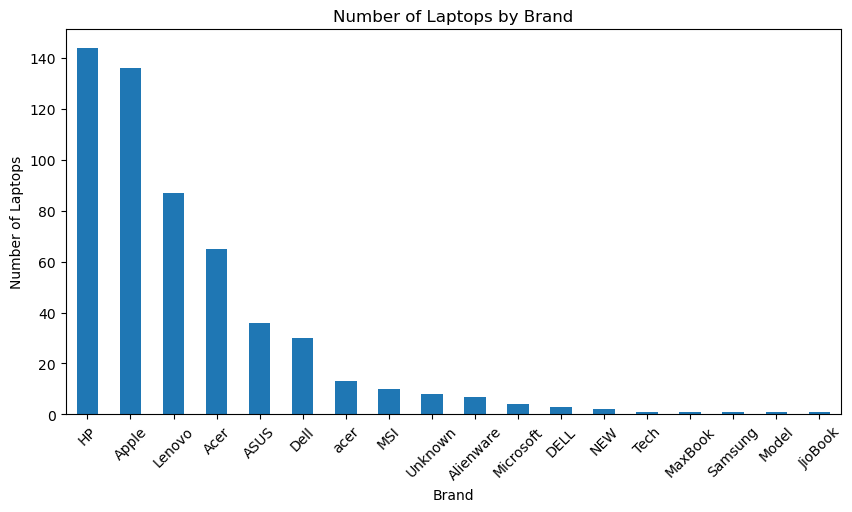

In [39]:
plt.figure(figsize=(10, 5))

df['brand'].value_counts().plot(kind='bar')

plt.xlabel('Brand')
plt.ylabel('Number of Laptops')
plt.title('Number of Laptops by Brand')

plt.xticks(rotation=45)
plt.show()

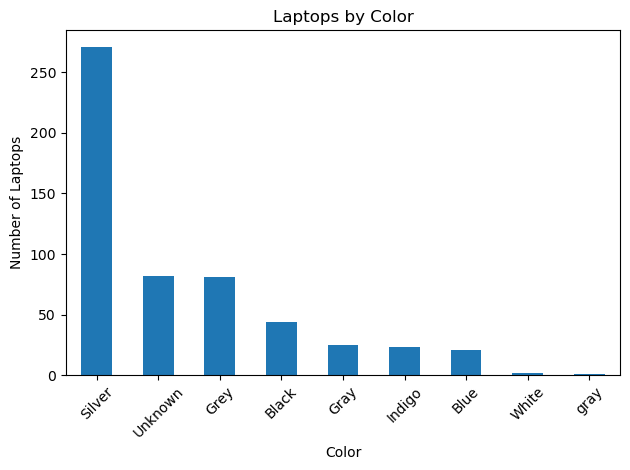

In [41]:
df["color"].value_counts().plot(kind="bar")

plt.title("Laptops by Color")
plt.xlabel("Color")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()